In [1]:
# Importing Libraries

import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import RandomizedSearchCV

In [2]:
modelling_data = pd.read_csv(r'/Users/Dell/Frudulent-transaction-detection-for-Finlora-Company/Finlora_Dataset/Artifacts/Engineered_Data.csv')

In [3]:
modelling_data.head()

,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,new_device,ip_country,...,hour,day_of_week,is_weekend,late_night_hours,amount_high,high_ip_risk,low_device_trust,new_account,very_new_account,velocity_spike
0,2022-10-03 18:40:59.468549+00:00,US,USD,CAD,atm,278.19,278.19,4.25,False,US,...,18,0,0,1,0,0,0,0,0,0
1,2022-10-03 20:39:38.468549+00:00,CA,CAD,MXN,web,208.51,154.29,4.24,True,CA,...,20,0,0,1,0,0,1,0,0,0
2,2022-10-03 23:02:43.468549+00:00,US,USD,CNY,mobile,160.33,160.33,2.70,False,US,...,23,0,0,1,0,0,0,0,0,0
3,2022-10-04 01:08:53.468549+00:00,US,USD,EUR,mobile,59.41,59.41,2.22,False,US,...,1,1,0,1,0,0,0,0,0,0
4,2022-10-04 09:35:03.468549+00:00,US,USD,INR,mobile,200.96,200.96,3.61,False,US,...,9,1,0,1,0,0,0,0,0,0


In [4]:
## Timestamp always needs to be in datetime format for any time series analysis or feature engineering. Therefore, we will convert the 'timestamp' column to datetime format.


modelling_data['timestamp'] = pd.to_datetime(modelling_data['timestamp'])

### Defining numerical and categorical features

In [5]:
categorical_features = modelling_data.select_dtypes(include=['object', 'bool']).columns 

categorical_features

/var/folders/13/c_bqr3w50896v5pg8y3p6zg80000gn/T/ipykernel_2373/2354712948.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = modelling_data.select_dtypes(include=['object', 'bool']).columns


Index(['home_country', 'source_currency', 'dest_currency', 'channel',
       'new_device', 'ip_country', 'location_mismatch', 'kyc_tier'],
      dtype='str')

In [6]:
numerical_features = modelling_data.select_dtypes(include=['int', 'float']).columns.drop('is_fraud')

numerical_features

Index(['amount_src', 'amount_usd', 'fee', 'ip_risk_score', 'account_age_days',
       'device_trust_score', 'risk_score_internal', 'txn_velocity_1h',
       'txn_velocity_24h', 'corridor_risk', 'hour', 'day_of_week',
       'is_weekend', 'late_night_hours', 'amount_high', 'high_ip_risk',
       'low_device_trust', 'new_account', 'very_new_account',
       'velocity_spike'],
      dtype='str')

In [7]:
all_features = list(categorical_features) + list(numerical_features)
print("all Features:")
print(all_features)

all Features:
['home_country', 'source_currency', 'dest_currency', 'channel', 'new_device', 'ip_country', 'location_mismatch', 'kyc_tier', 'amount_src', 'amount_usd', 'fee', 'ip_risk_score', 'account_age_days', 'device_trust_score', 'risk_score_internal', 'txn_velocity_1h', 'txn_velocity_24h', 'corridor_risk', 'hour', 'day_of_week', 'is_weekend', 'late_night_hours', 'amount_high', 'high_ip_risk', 'low_device_trust', 'new_account', 'very_new_account', 'velocity_spike']


Train_test Split
The data is split into: 80% of data used to train the model and 20% is reserved to test its performance on unseen data.
It is strongly recommended to sort the dataset chronologically before doing the train-test split. Since your dataset has a timestamp column, the order of events matters. This will prevent data leakage, help predict future transactions since model will trained on past transactions hence mimicing the real scenario.
Features like:txn_velocity_1h, txn_velocity_24h, new_device, account_age_days, new_account depend on historical order. If data is not ordered by time, these features can become incorrect.

In [8]:
#sorting by timestamp
modelling_data = modelling_data.sort_values(by='timestamp')

# 80/20 train test split

split_index = int(len(modelling_data) * 0.8) #This determines where the dataset should be split.
train_modelling_data = modelling_data.iloc[:split_index] #training on future transactions
test_modelling_data = modelling_data.iloc[split_index:] #testing on past transactions

# Prepare X and Y for training and testing
X_train = train_modelling_data[all_features]
Y_train = train_modelling_data['is_fraud']
X_test = test_modelling_data[all_features]
y_test = test_modelling_data['is_fraud']

print(f"\nx_train: {X_train.shape}, y_train: {Y_train.shape}")
print(f"x_test: {X_test.shape}, y_test: {y_test.shape}")


x_train: (8624, 28), y_train: (8624,)
x_test: (2156, 28), y_test: (2156,)


In [9]:
# Building a preprocessing pipeline for numerical and categorical features

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown="ignore"), categorical_features)
    ]
)

# Fit on train, transform both train and test
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(f"Original features: {len(all_features)}")
print(f"Processed features: {X_train_processed.shape[1]}")

Original features: 28
Processed features: 42


### Training Logistic Regression model with a balanced class weight to handle class imbalance



In [10]:
# create Logistic Regression model
ir_model = LogisticRegression(
    class_weight='balanced',
    random_state=42,
    max_iter=1000
)

# Building a complete pipeline

pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', ir_model)
    ]
)

# train the pipeline

pipeline.fit(X_train, Y_train)

# Make Predictions on the test set
y_pred_ir = pipeline.predict(X_test)
y_proba_ir = pipeline.predict_proba(X_test)[:, 1]  # Probability estimates for the positive class

# Evaluate the model
print("Logistic Regression Results:")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_ir, target_names=['Genuine', 'Fraud']))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_ir))
print(f"\nROC AUC Score: {roc_auc_score(y_test, y_proba_ir):.4f}")

Logistic Regression Results:

Classification Report:
              precision    recall  f1-score   support

     Genuine       0.99      0.96      0.97      1848
       Fraud       0.79      0.95      0.86       308

    accuracy                           0.96      2156
   macro avg       0.89      0.95      0.92      2156
weighted avg       0.96      0.96      0.96      2156


Confusion Matrix:
[[1771   77]
 [  16  292]]

ROC AUC Score: 0.9834


### Confusion matrix for linear regression

<Figure size 800x600 with 0 Axes>

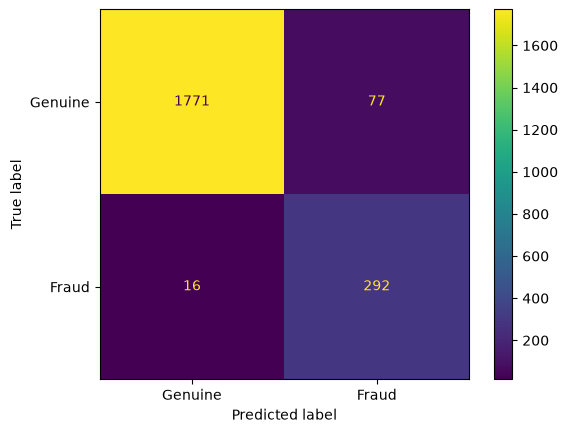

In [11]:
from sklearn.metrics import ConfusionMatrixDisplay

cm = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_ir), display_labels=['Genuine', 'Fraud'])
plt.figure(figsize=(8, 6))
cm.plot()

### Training Random Forest Classifier with balanced class weights to handle class imbalance

In [12]:
rf_model = RandomForestClassifier(
    class_weight='balanced',
    random_state=42,
    n_estimators=100,
    n_jobs=-1
)

# Bulding a complete pipeline for Random Forest Classifier
pipeline_rf = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', rf_model)
    ]
)

# Train the Random Forest pipeline using raw X_train, not the processed one, as the pipeline will handle preprocessing

pipeline_rf.fit(X_train, Y_train)

# Make Predictions on the test set
y_pred_rf = pipeline_rf.predict(X_test)
y_proba_rf = pipeline_rf.predict_proba(X_test)[:, 1]  #

# Evaluate the Random Forest model
print("Random Forest Classifier Results:")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, target_names=['Genuine', 'Fraud']))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))
print(f"\nROC AUC Score: {roc_auc_score(y_test, y_proba_rf)}")

Random Forest Classifier Results:

Classification Report:
              precision    recall  f1-score   support

     Genuine       0.99      1.00      0.99      1848
       Fraud       0.99      0.92      0.95       308

    accuracy                           0.99      2156
   macro avg       0.99      0.96      0.97      2156
weighted avg       0.99      0.99      0.99      2156


Confusion Matrix:
[[1845    3]
 [  25  283]]

ROC AUC Score: 0.9748921262719964


### Confusion matrix for random forest

<Figure size 800x600 with 0 Axes>

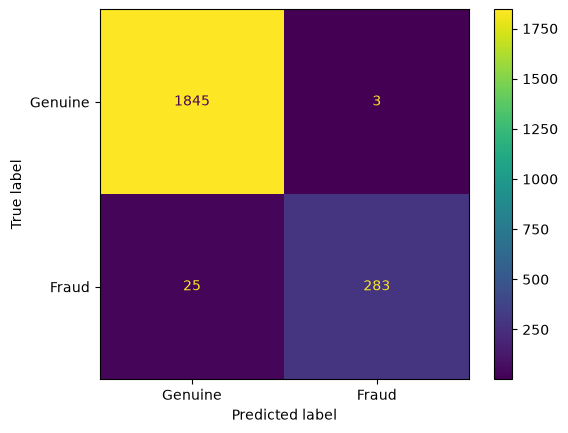

In [13]:
from sklearn.metrics import ConfusionMatrixDisplay

cm = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_rf), display_labels=['Genuine', 'Fraud'])
plt.figure(figsize=(8, 6))
cm.plot()

In [14]:
from xgboost import XGBClassifier

# Calculate scale pos weight for imbalance in xgboost classifier 

scale_pos_weight = (Y_train == 0).sum() / (Y_train == 1).sum()

# Create XGBoost model
xgb_model = XGBClassifier(
    random_state=42,
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss'
)
# Build the complete pipeline
pipeline_xgb = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', xgb_model)
    ]
)
# Train the pipeline (using raw X_train, not processed)

pipeline_xgb.fit(X_train, Y_train)

# Make predictions
y_pred_xgb = pipeline_xgb.predict(X_test)
y_proba_xgb = pipeline_xgb.predict_proba(X_test)[:, 1]

# Evaluation
print("XGBoost Results:")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb, target_names=['Genuine' , 'Fraud']))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))
print (f"\nROC_AUC Score: {roc_auc_score(y_test, y_proba_xgb):.4f}")

XGBoost Results:

Classification Report:
              precision    recall  f1-score   support

     Genuine       0.99      0.99      0.99      1848
       Fraud       0.94      0.92      0.93       308

    accuracy                           0.98      2156
   macro avg       0.96      0.96      0.96      2156
weighted avg       0.98      0.98      0.98      2156


Confusion Matrix:
[[1829   19]
 [  24  284]]

ROC_AUC Score: 0.9699


### Confusion matrix fpr xgboost

<Figure size 800x600 with 0 Axes>

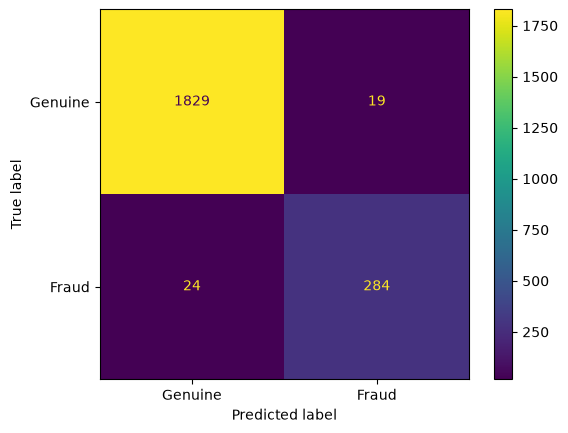

In [15]:
cm = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_xgb), display_labels=['Genuine', 'Fraud'])
plt.figure(figsize=(8, 6))
cm.plot()

### SHAP Analysis

SHAP is a game-theory tool that cracks open complex machine learning models, especially complex models like tree ensembles to show exactly how each feature impacts a decision. It answers one core question: "Why did the model label this specific transaction as fraud?"

It does this by assigning each feature a contribution value (Apsitive or negative) to the prediction. SHAP is used to interpret model predictions by quantifying the contribution of each feature to fraud risk. This enables transparency in decision-making, helped identify key fraud drivers such as transaction velocity and IP risk score, and provided actionable insights for fraud analysts and business stakeholders.

SHAP is based on Game Theory, specifically Shapley values. It fairly distributes the "credit" of a prediction across features.

In [16]:
import xgboost

print("XGBoost version:", xgboost.__version__)


XGBoost version: 2.1.4


In [17]:
%pip install --no-cache-dir --force-reinstall shap


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 30.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 61.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.5/40.5 MB 12.2 MB/s  0:00:03m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 3.5 MB/s  0:00:02eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 3.4 MB/s  0:00:02 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.5/20.5 MB 3.2 MB/s  0:00:06 eta 0:00:01
  Attempting uninstall: tqdm
    Found existing installation: tqdm 4.70.1
    Uninstalling tqdm-4.70.1:
      Successfully uninstalled tqdm-4.70.1
  Attempting uninstall: threadpoolctl
    Found existing installation: threadpoolctl 3.7.0
    Uninstalling threadpoolctl-3.7.0:
      Successfully uninstalled threadpoolctl-3.7.0━━━━━━━━━━━━━━━━  1/16 [threadpoolctl]
  Attempting uninstall: slicer━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━  1/16 [threadpoolctl]
    Found existing installation: slicer 0.0.8━━━━━━

In [18]:
import xgboost as xgb
import shap

print("SHAP version:", shap.__version__)
print("XGBoost version:", xgboost.__version__)

/Users/Dell/Frudulent-transaction-detection-for-Finlora-Company/finlora_env/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


SHAP version: 0.52.0
XGBoost version: 2.1.4


In [19]:
import shap
import pandas as pd 
import matplotlib.pyplot as plt

# Get the preprocessor from pipeline and transform raw X_test
X_test_processed = pipeline_xgb.named_steps['preprocessor'].transform(X_test)

# Get the XGBoost model from pipeline
xgb_model = pipeline_xgb.named_steps['classifier']

# Get booster and calculate SHAP values
booster = xgb_model.get_booster()
explainer = shap.TreeExplainer(booster)
shap_values_gb = explainer.shap_values(X_test_processed)



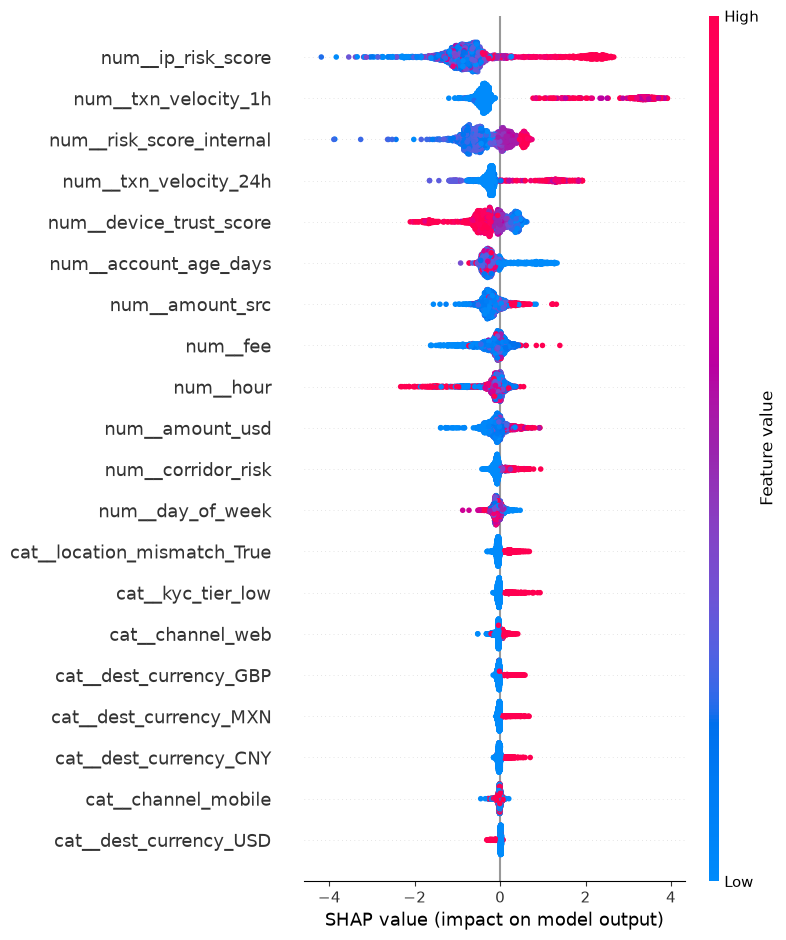

In [20]:
# Creating a clean feature name for the shap plot
feature_names = pipeline_xgb.named_steps['preprocessor'].get_feature_names_out()
clean_names = [name.replace("num ", "").replace(" cat ", "") for name in feature_names]

X_test_processed_df = pd.DataFrame(
    X_test_processed, 
    columns=clean_names
)

# Beeswarm plot
shap.summary_plot(shap_values_gb, X_test_processed_df)
plt.show()

This is a SHAP beeswarm plot, and it shows which features matter most and how they influence fraud predictions. The Y-axis shows the features (ranked by importance) while the X-axis shows the SHAP value (impact on prediction). The Blue color represents Low feature value while the red color represents High feature value.

The Left part of the plot negative SHAP value) pushes prediction toward Genuine while the Right part (positive SHAP value) pushes prediction toward Fraud.

The SHAP beeswarm plot highlights that transaction velocity spikes, location mismatch, internal risk scores, and IP risk scores are the most influential drivers of fraud predictions. High values of these features consistently push predictions toward fraud, while low values indicate genuine behaviour. The model captures a combination of behavioural anomalies, identity inconsistencies, and account risk factors, aligning closely with real-world fraud detection

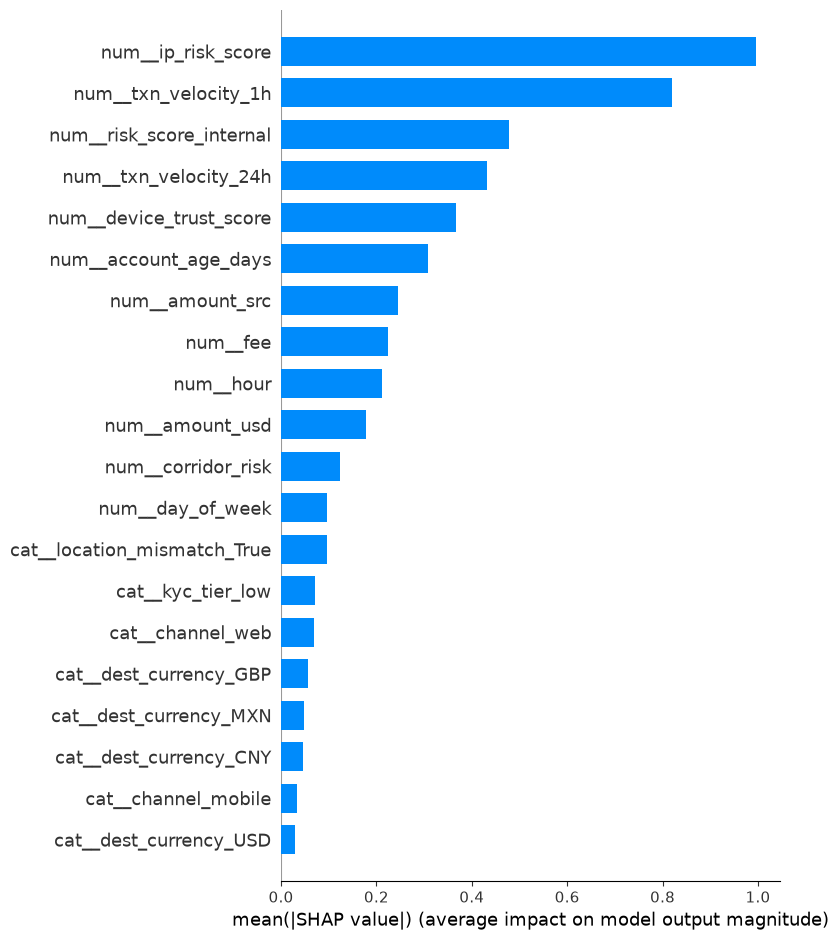

In [21]:
# Summary bar plot
shap.summary_plot(shap_values_gb, X_test_processed_df, plot_type="bar")
plt.show()

### Model registering

In [23]:
import dagshub 
import mlflow 
import mlflow.sklearn
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Initialize DagsHub
import dagshub
dagshub.init(repo_owner='elizabethehuine', 
             repo_name='Frudulent-transaction-detection-for-Finlora-Company', 
             mlflow=True)


❗❗❗ AUTHORIZATION REQUIRED ❗❗❗

/Users/Dell/Frudulent-transaction-detection-for-Finlora-Company/finlora_env/lib/python3.13/site-packages/rich/live.
py:260: UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')



Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=6d39fa77-ece8-4fb7-a0b0-aa2f386fa3bd&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=b8ea4bcd8aaa8e0419dd31e4d1097cf6bc81ae89115bdcdd933b66f2596be1b4




Accessing as elizabethehuine

Initialized MLflow to track repo "elizabethehuine/Frudulent-transaction-detection-for-Finlora-Company"

Repository elizabethehuine/Frudulent-transaction-detection-for-Finlora-Company initialized!

In [25]:
# Set experiment
from xml.dom.domreg import registered


mlflow.set_experiment("Fraudulent_Transaction_Detection_Model_for_Finlora_Company")

# Start MLflow run and register model
with mlflow.start_run() as run:
    # Log model parameters
    mlflow.log_params(xgb_model.get_params())
    
# Make predictions using the pipeline
y_pred = pipeline_xgb.predict(X_test)
y_pred_proba = pipeline_xgb.predict_proba(X_test) [:, 1]

# Log model metrics
mlflow.log_metrics({
    "accuracy": accuracy_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred),
    "recall": recall_score(y_test, y_pred),
    "f1_score": f1_score(y_test, y_pred),
    "roc_auc": roc_auc_score(y_test, y_pred_proba)
})

# Log the entire pipeline as a model (including preprocessing + model) with cloudpickle serialization
mlflow.sklearn.log_model(
    pipeline_xgb, 
    "xgboost_fraud_detection_pipeline",
    registered_model_name="Fraud_Detection_XGBoost_Pipeline",
    serialization_format='cloudpickle'
)

print("Model registered successfully!")
print(f"Run ID: {run.info.run_id}")

2026/09/30 14:53:05 INFO mlflow.tracking.fluent: Experiment with name 'Fraudulent_Transaction_Detection_Model_for_Finlora_Company' does not exist. Creating a new experiment.


🏃 View run crawling-flea-60 at: https://dagshub.com/elizabethehuine/Frudulent-transaction-detection-for-Finlora-Company.mlflow/#/experiments/0/runs/f294ccbfb7f040b68c7cf6008506440e
🧪 View experiment at: https://dagshub.com/elizabethehuine/Frudulent-transaction-detection-for-Finlora-Company.mlflow/#/experiments/0


2026/09/30 14:53:07 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/09/30 14:53:09 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Successfully registered model 'Fraud_Detection_XGBoost_Pipeline'.
2026/09/30 14:53:35 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: Fraud_Detection_XGBoost_Pipeline, version 1
Created version '1' of model 'Fraud_Detection_XGBoost_Pipeline'.


Model registered successfully!
Run ID: f294ccbfb7f040b68c7cf6008506440e
